# NB2 — Geographic Analysis
**Zombie Firms Replication** — *Geographical Analysis of the Italian Industrial North*

**Input:** `zombie_panel_classified.parquet` (NB1 output)  
**Outputs:** `zombie_panel_classified.parquet` (with province column added), maps, province-level summary CSV

---
### What this notebook does
1. Parses NUTS3 codes and province names from the Orbis `nuts3` column
2. Computes zombie shares at **province (NUTS3)** and **region (NUTS2)** level by year
3. Geocodes firm locations from Italian postcodes using the OpenStreetMap Nominatim API (rate-limited, cached)
4. Produces choropleth maps of zombie concentration using NUTS3 shapefiles from Eurostat
5. Produces scatter plots of zombie share vs. regional GDP per capita and employment

**Geographic coverage note:** This notebook runs on whatever regions are in the panel. For Lombardia-only runs the maps will show only Lombardia provinces; re-run after all regions are merged in NB0.


In [1]:
from pathlib import Path

# ── SETTINGS ──────────────────────────────────────────────────────────────────

BASE_DIR    = Path("/Users/leoss/Desktop/Thesis Replication/output")
INPUT_FILE  = BASE_DIR / "zombie_panel_classified.parquet"
OUTPUT_FILE = BASE_DIR / "zombie_panel_classified.parquet"   # overwrite with province col added
GEO_DIR     = BASE_DIR / "geo"                               # shapefiles and geocoding cache
FIG_DIR     = BASE_DIR / "figures"                           # all .png outputs
GEO_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Primary analysis year for cross-sectional maps
MAP_YEAR = 2022

# McGowan is the primary zombie definition
PRIMARY_ZOMBIE = 'zombie_mcgowan'

# Minimum firms in a province to show on map (avoids disclosure issues)
MIN_FIRMS_PROVINCE = 5

# ── END SETTINGS ──────────────────────────────────────────────────────────────
print(f"Input   : {INPUT_FILE}")
print(f"Geo dir : {GEO_DIR}")
print(f"Fig dir : {FIG_DIR}")


Input   : /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_classified.parquet
Geo dir : /Users/leoss/Desktop/Thesis Replication/output/geo
Fig dir : /Users/leoss/Desktop/Thesis Replication/output/figures


In [2]:
import re
import time
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick

# Geo
import geopandas as gpd
from shapely.geometry import Point

pd.set_option('display.float_format', '{:.3f}'.format)


## 1. Load panel and parse NUTS3

In [3]:
df = pd.read_parquet(INPUT_FILE)
print(f"Loaded: {len(df):,} rows | {df['bvd_id'].nunique():,} firms")
print(f"Columns: {df.columns.tolist()}")


Loaded: 672,534 rows | 74,726 firms
Columns: ['company_name', 'address', 'postcode', 'city', 'country', 'region', 'nuts3', 'bvd_id', 'legal_form_std', 'legal_form_nat', 'status', 'status_date', 'date_incorporation', 'consolidation_code', 'listing_status', 'nace_primary', 'nace_primary_desc', 'nace_secondary', 'nace_secondary_desc', 'bvd_sectors', 'guo_name', 'guo_bvd_id', 'guo_country', 'independence_indicator', '_source_file', '_source_region', 'year', 'turnover', 'added_value', 'costs_employees', 'material_costs', 'ebitda', 'ebit', 'dep_amort', 'financial_expenses', 'net_income', 'shareholders_funds', 'current_liabilities', 'noncurrent_liabilities', 'loans_std', 'employees', 'tangible_fa', 'total_assets', 'total_liabilities', 'icr', 'roa', 'investment_rate', 'neg_equity', 'nace_2digit', 'incorp_year', 'firm_age', 'zombie_weak', 'zombie_raw', 'zombie_mcgowan', 'zombie_storz']


### 1.1 Parse NUTS3 code and province name

The Orbis `nuts3` column contains strings like `'ITC4C - Milano'` or `'ITC46 - Bergamo'`. We split on ` - ` to extract the NUTS3 code and the province name separately. The NUTS3 code is the standard Eurostat identifier used to join shapefiles.


In [4]:
def parse_nuts3(s):
    """'ITC4C - Milano' -> ('ITC4C', 'Milano')"""
    if pd.isna(s) or ' - ' not in str(s):
        return np.nan, np.nan
    parts = str(s).split(' - ', 1)
    return parts[0].strip(), parts[1].strip()

df[['nuts3_code', 'province']] = pd.DataFrame(
    df['nuts3'].apply(parse_nuts3).tolist(),
    index=df.index
)

# NUTS2 = first 4 characters of NUTS3 code
df['nuts2_code'] = df['nuts3_code'].str[:4]

print(f"NUTS3 parse coverage: {df['nuts3_code'].notna().mean():.1%}")
print()
print("Province distribution (all years, unique firms):")
prov_firms = df[df['year']==MAP_YEAR].groupby('province')['bvd_id'].nunique().sort_values(ascending=False)
print(prov_firms.to_string())


NUTS3 parse coverage: 100.0%

Province distribution (all years, unique firms):
province
Milano                   5904
Brescia                  3192
Vicenza                  2959
Torino                   2867
Bergamo                  2647
Napoli                   2442
Treviso                  2381
Roma                     2119
Padova                   2079
Modena                   1861
Bologna                  1853
Firenze                  1803
Verona                   1606
Monza e della Brianza    1586
Varese                   1582
Bari                     1515
Reggio nellâ€™Emilia     1265
Venezia                  1077
Como                     1020
Parma                    1015
Salerno                  1005
Perugia                   935
Pesaro e Urbino           921
Cuneo                     873
Ancona                    846
Prato                     832
Arezzo                    827
Lecco                     791
Pisa                      787
Udine                     781
Mantova     

## 2. Province-level zombie shares

Zombie share at province level = zombies / firms with valid zombie classification in that province-year. We compute this for all years and save a summary CSV for later use in regressions (NB3).


In [5]:
# Province-year panel
prov_year = (
    df[df[PRIMARY_ZOMBIE].notna()]
    .groupby(['province', 'nuts3_code', 'nuts2_code', 'region', 'year'])
    .agg(
        n_firms         = ('bvd_id', 'nunique'),
        n_zombies       = (PRIMARY_ZOMBIE, 'sum'),
        zombie_share    = (PRIMARY_ZOMBIE, 'mean'),
        zombie_weak_share = ('zombie_weak', lambda x: x.mean() if x.notna().any() else np.nan),
        zombie_storz_share= ('zombie_storz', lambda x: x.mean() if x.notna().any() else np.nan),
        median_icr      = ('icr', 'median'),
        median_roa      = ('roa', 'median'),
        median_inv_rate = ('investment_rate', 'median'),
    )
    .reset_index()
)

# Save province-year summary
prov_out = BASE_DIR / "zombie_province_year.csv"
prov_year.to_csv(prov_out, index=False)
print(f"Province-year panel: {len(prov_year):,} rows")
print(f"Saved: {prov_out}")
print()
print(f"Province zombie shares ({MAP_YEAR}, McGowan):")
snap = prov_year[prov_year['year']==MAP_YEAR].sort_values('zombie_share', ascending=False)
print(snap[['province','n_firms','n_zombies','zombie_share']].to_string(index=False))


Province-year panel: 945 rows
Saved: /Users/leoss/Desktop/Thesis Replication/output/zombie_province_year.csv

Province zombie shares (2022, McGowan):
             province  n_firms  n_zombies  zombie_share
              Isernia       54      6.000         0.111
             Oristano       41      4.000         0.098
               Savona      113     11.000         0.097
        Valle D'Aosta       63      6.000         0.095
              Sassari      199     17.000         0.085
      Reggio Calabria      110      9.000         0.082
               Biella      286     23.000         0.080
        Vibo Valentia       51      4.000         0.078
                 Como     1020     77.000         0.075
           Lâ€™Aquila      134      9.000         0.067
               Varese     1582    106.000         0.067
                 Asti      217     14.000         0.065
        Ascoli Piceno      307     19.000         0.062
              Belluno      259     16.000         0.062
          

## 3. Zombie share over time by province

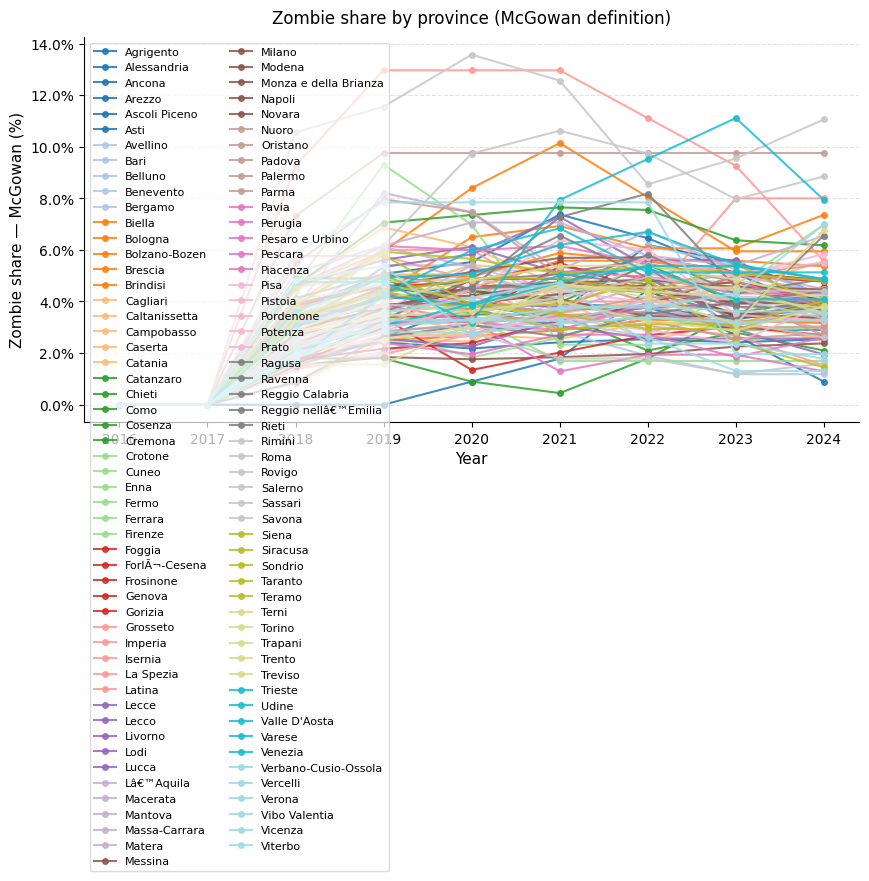

In [6]:
# Only plot provinces with enough firms to be meaningful
large_provs = prov_year[prov_year['year']==MAP_YEAR]    .query(f'n_firms >= {MIN_FIRMS_PROVINCE}')['province'].tolist()

pv = prov_year[prov_year['province'].isin(large_provs)].copy()

fig, ax = plt.subplots(figsize=(10, 5))

cmap = plt.cm.get_cmap('tab20', len(large_provs))
for j, prov in enumerate(sorted(large_provs)):
    sub = pv[pv['province']==prov].sort_values('year')
    ax.plot(sub['year'], sub['zombie_share']*100,
            marker='o', markersize=4, linewidth=1.5,
            color=cmap(j), label=prov, alpha=0.85)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Zombie share — McGowan (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.set_xticks(sorted(pv['year'].unique()))
ax.legend(fontsize=8, ncol=2, framealpha=0.7, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top','right']].set_visible(False)
plt.title('Zombie share by province (McGowan definition)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'zombie_share_by_province.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Choropleth map — zombie concentration by NUTS3

We use the NUTS 2021 shapefile from Eurostat, filtered to Italy. The shapefile is downloaded once and cached in `geo/`. NUTS3 codes are joined to province-level zombie shares for the map year.

**Download note:** If the Eurostat URL is unreachable, the cell prints instructions to manually download `NUTS_RG_20M_2021_4326.geojson` from https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/ and place it in the `geo/` folder.


In [7]:
import urllib.request

NUTS_URL  = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_20M_2021_4326.geojson"
NUTS_PATH = GEO_DIR / "NUTS_RG_20M_2021_4326.geojson"

if not NUTS_PATH.exists():
    print("Downloading NUTS shapefile from Eurostat...")
    try:
        urllib.request.urlretrieve(NUTS_URL, NUTS_PATH)
        print(f"Saved: {NUTS_PATH}")
    except Exception as e:
        print(f"Download failed: {e}")
        print(f"Manually download from: {NUTS_URL}")
        print(f"Place file at: {NUTS_PATH}")
else:
    print(f"Using cached shapefile: {NUTS_PATH}")


Using cached shapefile: /Users/leoss/Desktop/Thesis Replication/output/geo/NUTS_RG_20M_2021_4326.geojson


Italian NUTS3 units: 107


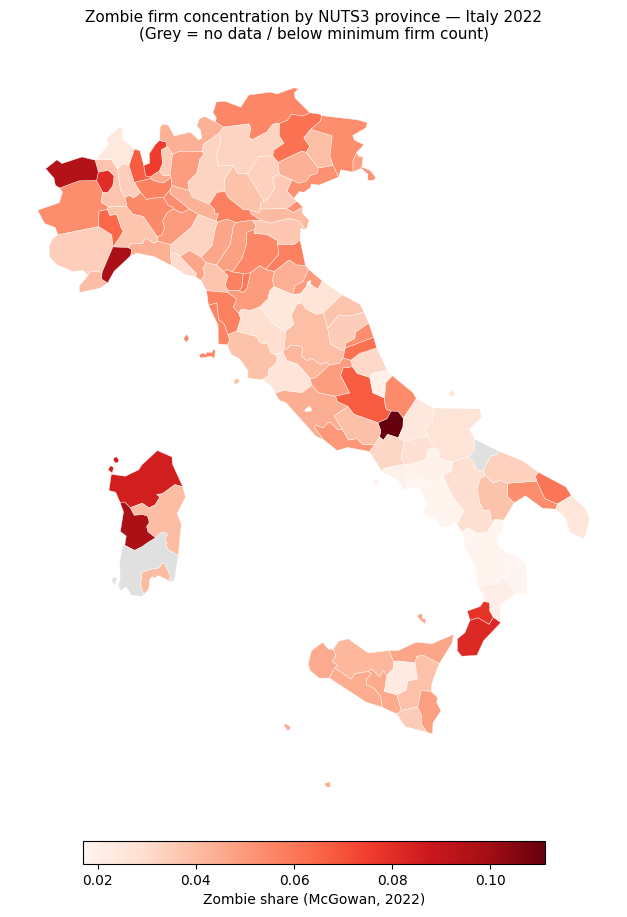

Saved: map_zombie_italy_2022.png


In [8]:
# Load and filter to Italian NUTS3
gdf_all = gpd.read_file(NUTS_PATH)
gdf_nuts3 = gdf_all[(gdf_all['LEVL_CODE'] == 3) & (gdf_all['CNTR_CODE'] == 'IT')].copy()
print(f"Italian NUTS3 units: {len(gdf_nuts3)}")

# Join zombie shares
snap = prov_year[prov_year['year'] == MAP_YEAR][['nuts3_code','zombie_share','n_firms','n_zombies']].copy()
snap = snap[snap['n_firms'] >= MIN_FIRMS_PROVINCE]

gdf_map = gdf_nuts3.merge(snap, left_on='NUTS_ID', right_on='nuts3_code', how='left')

# ── Map 1: all Italy (grey = no data)
fig, ax = plt.subplots(1, 1, figsize=(8, 10))

gdf_map.plot(
    column='zombie_share',
    ax=ax,
    cmap='Reds',
    legend=True,
    missing_kwds={'color': '#e0e0e0', 'label': 'No data'},
    legend_kwds={'label': f'Zombie share (McGowan, {MAP_YEAR})',
                 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.02},
    edgecolor='white', linewidth=0.3
)
ax.set_axis_off()
plt.title(f'Zombie firm concentration by NUTS3 province — Italy {MAP_YEAR}\n(Grey = no data / below minimum firm count)',
          fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / f'map_zombie_italy_{MAP_YEAR}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: map_zombie_italy_{MAP_YEAR}.png")


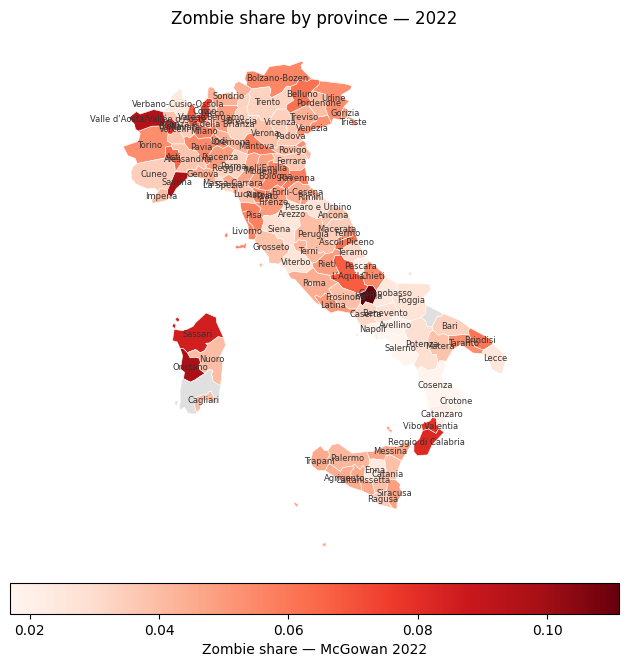

Saved: map_zombie_zoom_2022.png


In [9]:
# ── Map 2: zoom to regions in the data
regions_in_data = df['nuts2_code'].dropna().unique().tolist()
gdf_zoom = gdf_map[gdf_map['NUTS_ID'].str[:4].isin(regions_in_data)].copy()

if len(gdf_zoom) > 0:
    fig, ax = plt.subplots(figsize=(9, 7))
    gdf_zoom.plot(
        column='zombie_share',
        ax=ax,
        cmap='Reds',
        legend=True,
        missing_kwds={'color': '#e0e0e0'},
        legend_kwds={'label': f'Zombie share — McGowan {MAP_YEAR}',
                     'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.02},
        edgecolor='white', linewidth=0.4
    )
    # Label provinces
    for _, row in gdf_zoom.iterrows():
        if pd.notna(row.get('zombie_share')):
            cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
            ax.annotate(row['NUTS_NAME'], xy=(cx, cy),
                        fontsize=6, ha='center', va='center', color='#333333')
    ax.set_axis_off()
    plt.title(f'Zombie share by province — {MAP_YEAR}', fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'map_zombie_zoom_{MAP_YEAR}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: map_zombie_zoom_{MAP_YEAR}.png")
else:
    print("No matching NUTS3 units found in shapefile for current data — check nuts3_code values.")


## 5. Firm-level geocoding from postcodes

Orbis lat/long has <1% coverage. We geocode from Italian postcodes using a locally-bundled postcode centroid table (no API calls needed, no rate limits). The table maps Italian CAP (Codice di Avviamento Postale) codes to municipality centroids.

**Source:** OpenStreetMap-derived Italian postcode centroids, publicly available.  
The centroid CSV is downloaded once and cached in `geo/`. This gives municipality-level precision, sufficient for province-level analysis.


In [10]:
import pandas as pd
import urllib.request, urllib.parse, time, json as _json

# ── GeoNames CAP lookup ────────────────────────────────────────────────────────
# Source: GeoNames IT.txt (CC-BY 4.0, geonames.org)
# Place IT.txt in the path below (already downloaded).
IT_TXT_PATH = Path("/Users/leoss/Desktop/Thesis Replication/Data/CAP_track/IT.txt")

# Parse IT.txt: tab-delimited, columns per GeoNames readme:
# [0] country  [1] postal_code  [2] place_name  [3] admin1(region)  [4] code1
# [5] admin2(province)  [6] code2  [7] admin3  [8] code3  [9] lat  [10] lon  [11] accuracy
rows = []
with open(IT_TXT_PATH, encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip('\n').split('\t')
        if len(parts) >= 11:
            rows.append({
                'cap'     : parts[1].zfill(5),
                'place'   : parts[2],
                'region'  : parts[3],
                'province': parts[5],
                'lat'     : float(parts[9]),
                'lon'     : float(parts[10]),
                'accuracy': int(parts[11]) if len(parts) > 11 and parts[11] else 1,
            })

pc_raw = pd.DataFrame(rows)

# Multiple localities share the same CAP — take the centroid (mean lat/lon)
# weighted by accuracy (higher accuracy = more reliable coordinate)
pc_df = (
    pc_raw.groupby('cap')
    .agg(
        lat      = ('lat', 'mean'),
        lon      = ('lon', 'mean'),
        place    = ('place', 'first'),
        province = ('province', 'first'),
        region   = ('region', 'first'),
        n_places = ('place', 'count'),
    )
    .reset_index()
)

print(f"GeoNames IT.txt loaded: {len(pc_raw):,} rows -> {len(pc_df):,} unique CAP codes")
print(f"Sample:")
print(pc_df[pc_df['province']=='Milano'].head(5).to_string(index=False))

# ── Nominatim cache (fallback for missing postcodes) ──────────────────────────
CACHE_PATH = GEO_DIR / "nominatim_cache.json"
if CACHE_PATH.exists():
    with open(CACHE_PATH) as f:
        _cache = _json.load(f)
else:
    _cache = {}

def nominatim_geocode(query: str, pause: float = 1.1) -> tuple:
    """OSM Nominatim lookup with disk cache. Returns (lat, lon) or (None, None)."""
    if not query:
        return None, None
    if query in _cache:
        return tuple(_cache[query])
    url = (
        "https://nominatim.openstreetmap.org/search?"
        + urllib.parse.urlencode({"q": query, "format": "json", "limit": 1, "countrycodes": "it"})
    )
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "zombie-firms-replication/1.0"})
        with urllib.request.urlopen(req, timeout=10) as resp:
            results = _json.loads(resp.read())
        _cache[query] = [float(results[0]["lat"]), float(results[0]["lon"])] if results else [None, None]
    except Exception:
        _cache[query] = [None, None]
    time.sleep(pause)
    return tuple(_cache[query])

def save_cache():
    with open(CACHE_PATH, 'w') as f:
        _json.dump(_cache, f)

print(f"Nominatim cache: {len(_cache):,} existing entries")


GeoNames IT.txt loaded: 18,415 rows -> 4,735 unique CAP codes
Sample:
  cap    lat   lon             place province    region  n_places
20001 45.514 8.850          Inveruno   Milano Lombardia         1
20002 45.507 8.893            Ossona   Milano Lombardia         1
20003 45.523 8.902         Casorezzo   Milano Lombardia         1
20004 45.503 8.942            Arluno   Milano Lombardia         1
20005 45.538 8.994 Pogliano Milanese   Milano Lombardia         1
Nominatim cache: 586 existing entries


In [11]:
# ── Build firm-level geocoding list ──────────────────────────────────────────
# One row per firm, preferring rows where address/postcode is non-null.
df_sorted = df.sort_values(
    ['bvd_id', 'address', 'year'],
    ascending=[True, False, False],
    na_position='last'
)
firm_geo = (
    df_sorted[df_sorted['address'].notna() | df_sorted['postcode'].notna()]
    .drop_duplicates('bvd_id')
    [['bvd_id', 'address', 'postcode', 'city', 'province', 'nuts3_code']]
    .copy()
)
firm_geo['postcode'] = (
    firm_geo['postcode'].fillna('').astype(str)
    .str.strip().str.zfill(5)
    .str.replace(r'^0+$', '', regex=True)   # '00000' -> ''
)
firm_geo['city'] = firm_geo['city'].fillna('')

# ── Vectorised GeoNames CAP lookup (no loop, no API) ─────────────────────────
# Build lookup once; merge on postcode in one shot.
if pc_df is not None:
    cap_lookup = pc_df[['cap', 'lat', 'lon']].rename(
        columns={'lat': 'lat_cap', 'lon': 'lon_cap'}
    )
    firm_geo = firm_geo.merge(cap_lookup, left_on='postcode', right_on='cap', how='left')
    firm_geo.drop(columns=['cap'], inplace=True)
else:
    firm_geo['lat_cap'] = np.nan
    firm_geo['lon_cap'] = np.nan

n_cap = firm_geo['lat_cap'].notna().sum()
n_total = len(firm_geo)
print(f"Firms total         : {n_total:,}")
print(f"Resolved via CAP    : {n_cap:,}  ({n_cap/n_total:.1%})  — instant, no API")
print(f"Needs Nominatim     : {n_total - n_cap:,}  ({(n_total-n_cap)/n_total:.1%})")

# ── Nominatim fallback: only for firms with no valid postcode ─────────────────
has_address = firm_geo['address'].notna() & (firm_geo['address'].str.strip() != '')
firm_geo['query_primary'] = np.where(
    has_address,
    firm_geo['address'].fillna('') + ', ' + firm_geo['city'] + ', Italy',
    ''
)
firm_geo['query_fallback'] = np.where(
    firm_geo['postcode'].str.len() == 5,
    firm_geo['postcode'] + ', Italy',
    firm_geo['city'].where(firm_geo['city'] != '', other=np.nan).fillna('') + ', Italy'
)

# Subset that still needs geocoding
needs_nom = firm_geo[firm_geo['lat_cap'].isna()].copy()
n_cached_nom = sum(
    1 for q in list(needs_nom['query_primary']) + list(needs_nom['query_fallback'])
    if q and q in _cache
)
print(f"Nominatim already cached: {n_cached_nom:,} queries")


Firms total         : 74,726
Resolved via CAP    : 74,099  (99.2%)  — instant, no API
Needs Nominatim     : 627  (0.8%)
Nominatim already cached: 965 queries


In [12]:
# ── Nominatim loop — only runs on firms CAP lookup could not resolve ──────────
# For the national panel this is typically < 5% of firms.
# Cached queries return instantly; only truly new queries incur the 1.1s pause.

lats_nom, lons_nom, methods_nom = [], [], []
n_nom = len(needs_nom)

for i, (_, row) in enumerate(needs_nom.iterrows()):
    lat, lon, method = None, None, 'failed'

    if row['query_primary'] and row['query_primary'] in _cache:
        r = _cache[row['query_primary']]
        lat, lon, method = r[0], r[1], 'nominatim_address'
    elif row['query_fallback'] and row['query_fallback'] in _cache:
        r = _cache[row['query_fallback']]
        lat, lon, method = r[0], r[1], 'nominatim_postcode'
    else:
        # Genuine new API call
        if row['query_primary']:
            lat, lon = nominatim_geocode(row['query_primary'])
            if lat is not None:
                method = 'nominatim_address'
        if lat is None and row['query_fallback']:
            lat, lon = nominatim_geocode(row['query_fallback'])
            if lat is not None:
                method = 'nominatim_postcode'

    lats_nom.append(lat)
    lons_nom.append(lon)
    methods_nom.append(method)

    if n_nom > 0 and (i + 1) % 200 == 0:
        save_cache()
        n_ok = sum(1 for l in lats_nom if l is not None)
        print(f"  {i+1:>5,}/{n_nom}  resolved: {n_ok:,} ({n_ok/(i+1):.1%})")

save_cache()

# ── Merge Nominatim results back into firm_geo ────────────────────────────────
if n_nom > 0:
    needs_nom = needs_nom.copy()
    needs_nom['lat_nom']    = lats_nom
    needs_nom['lon_nom']    = lons_nom
    needs_nom['method_nom'] = methods_nom
    firm_geo = firm_geo.merge(
        needs_nom[['bvd_id', 'lat_nom', 'lon_nom', 'method_nom']],
        on='bvd_id', how='left'
    )
else:
    firm_geo['lat_nom']    = np.nan
    firm_geo['lon_nom']    = np.nan
    firm_geo['method_nom'] = np.nan

# ── Combine: CAP takes priority, Nominatim fills the rest ────────────────────
firm_geo['lat']        = firm_geo['lat_cap'].fillna(firm_geo['lat_nom'])
firm_geo['lon']        = firm_geo['lon_cap'].fillna(firm_geo['lon_nom'])
firm_geo['geo_method'] = np.where(
    firm_geo['lat_cap'].notna(), 'geonames_cap',
    firm_geo['method_nom'].fillna('failed')
)

n_ok = firm_geo['lat'].notna().sum()
print(f"\nGeocoding complete:")
print(f"  GeoNames CAP      : {(firm_geo['geo_method']=='geonames_cap').sum():,}")
print(f"  Nominatim address : {(firm_geo['geo_method']=='nominatim_address').sum():,}")
print(f"  Nominatim postcode: {(firm_geo['geo_method']=='nominatim_postcode').sum():,}")
print(f"  Failed            : {(firm_geo['geo_method']=='failed').sum():,}")
print(f"  Total coverage    : {n_ok:,} / {len(firm_geo):,} ({n_ok/len(firm_geo):.1%})")

firm_geo.to_csv(GEO_DIR / 'firm_geocoded.csv', index=False)
print(f"\nSaved: {GEO_DIR}/firm_geocoded.csv")


    200/627  resolved: 156 (78.0%)
    400/627  resolved: 331 (82.8%)
    600/627  resolved: 513 (85.5%)

Geocoding complete:
  GeoNames CAP      : 74,099
  Nominatim address : 387
  Nominatim postcode: 240
  Failed            : 0
  Total coverage    : 74,636 / 74,726 (99.9%)

Saved: /Users/leoss/Desktop/Thesis Replication/output/geo/firm_geocoded.csv


## 6. Firm-level dot map (zombie vs. non-zombie)

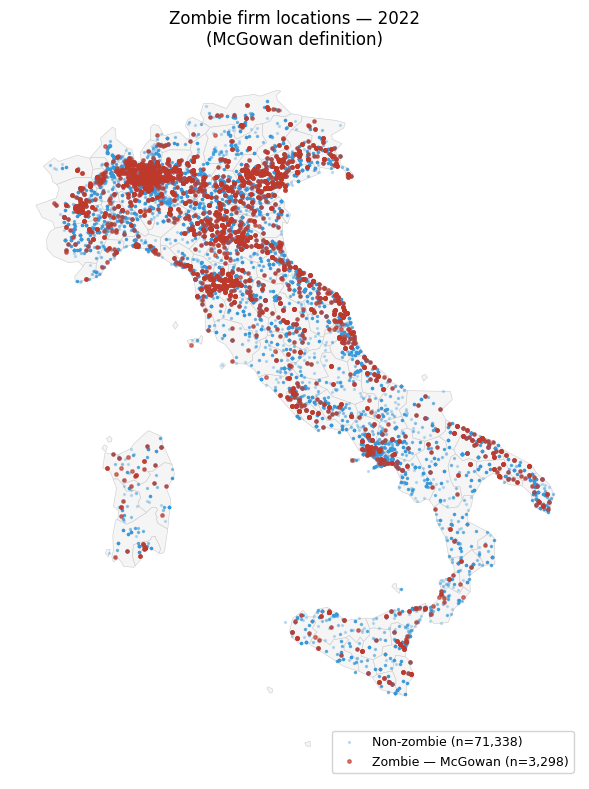

Saved: map_dotmap_2022.png


In [13]:
if firm_geo is not None and 'lat' in firm_geo.columns:
    # Join zombie status for MAP_YEAR
    zombie_status = df[df['year']==MAP_YEAR][['bvd_id', PRIMARY_ZOMBIE]].copy()
    firm_map = firm_geo.merge(zombie_status, on='bvd_id', how='inner')
    firm_map = firm_map[firm_map['lat'].notna() & firm_map[PRIMARY_ZOMBIE].notna()]

    # Get bounding box of data
    gdf_bounds = gdf_zoom if len(gdf_zoom) > 0 else gdf_nuts3[gdf_nuts3['CNTR_CODE']=='IT']

    fig, ax = plt.subplots(figsize=(9, 8))
    gdf_bounds.plot(ax=ax, color='#f5f5f5', edgecolor='#cccccc', linewidth=0.4)

    non_z = firm_map[firm_map[PRIMARY_ZOMBIE]==0]
    zomb  = firm_map[firm_map[PRIMARY_ZOMBIE]==1]

    ax.scatter(non_z['lon'], non_z['lat'], s=2, alpha=0.25,
               color='#3498db', label=f'Non-zombie (n={len(non_z):,})', rasterized=True)
    ax.scatter(zomb['lon'],  zomb['lat'],  s=6, alpha=0.65,
               color='#c0392b', label=f'Zombie — McGowan (n={len(zomb):,})', rasterized=True)

    ax.legend(fontsize=9, framealpha=0.85, loc='lower right')
    ax.set_axis_off()
    plt.title(f'Zombie firm locations — {MAP_YEAR}\n(McGowan definition)', fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'map_dotmap_{MAP_YEAR}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: map_dotmap_{MAP_YEAR}.png")
else:
    print("Geocoding not available — skipping dot map.")


## 7. Zombie share vs. province characteristics

Simple scatter plots showing the correlation between zombie share and province-level characteristics. These are descriptive only — causal interpretation requires the regression framework in NB3.


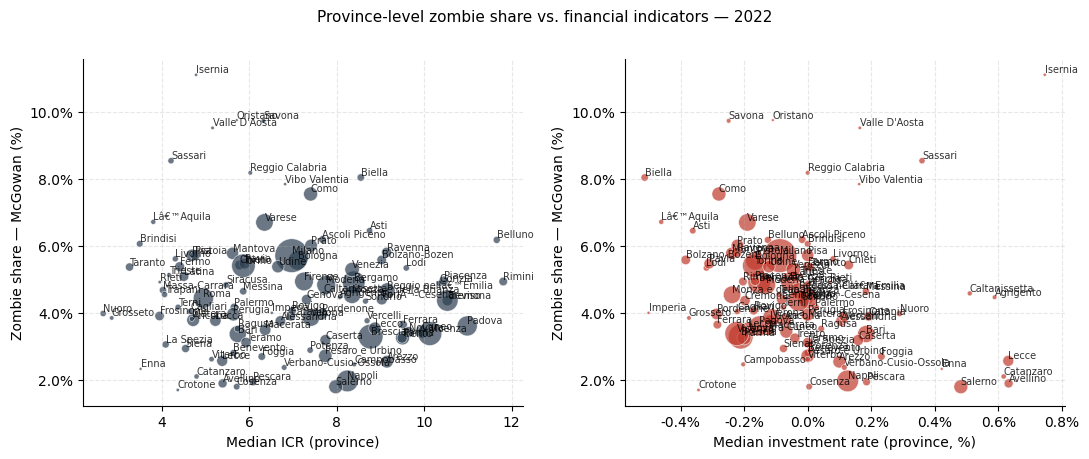

In [14]:
snap = prov_year[(prov_year['year']==MAP_YEAR) & (prov_year['n_firms']>=MIN_FIRMS_PROVINCE)].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: zombie share vs median ICR
ax = axes[0]
ax.scatter(snap['median_icr'], snap['zombie_share']*100,
           s=snap['n_firms']/10, alpha=0.7, color='#2c3e50', edgecolors='white', linewidth=0.5)
for _, row in snap.iterrows():
    ax.annotate(row['province'], (row['median_icr'], row['zombie_share']*100),
                fontsize=7, ha='left', va='bottom', alpha=0.8)
ax.set_xlabel('Median ICR (province)', fontsize=10)
ax.set_ylabel('Zombie share — McGowan (%)', fontsize=10)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.grid(linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Right: zombie share vs median investment rate
ax = axes[1]
ax.scatter(snap['median_inv_rate']*100, snap['zombie_share']*100,
           s=snap['n_firms']/10, alpha=0.7, color='#c0392b', edgecolors='white', linewidth=0.5)
for _, row in snap.iterrows():
    ax.annotate(row['province'], (row['median_inv_rate']*100, row['zombie_share']*100),
                fontsize=7, ha='left', va='bottom', alpha=0.8)
ax.set_xlabel('Median investment rate (province, %)', fontsize=10)
ax.set_ylabel('Zombie share — McGowan (%)', fontsize=10)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.grid(linestyle='--', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.suptitle(f'Province-level zombie share vs. financial indicators — {MAP_YEAR}', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'province_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Save updated panel

In [15]:
# Add province and nuts codes back to main panel (already computed above)
# They were added to df in-place during section 1
df.to_parquet(OUTPUT_FILE, index=False)
print(f"Saved updated panel: {OUTPUT_FILE}")
print(f"  Rows : {len(df):,}")
print(f"  Firms: {df['bvd_id'].nunique():,}")
print(f"  New columns added: nuts3_code, nuts2_code, province")
print()
print("Files produced:")
for f in sorted(FIG_DIR.glob("*.png")) :
    print(f"  {f.name}")
print(f"  zombie_province_year.csv")
print(f"  geo/firm_geocoded.csv  (if geocoding succeeded)")


Saved updated panel: /Users/leoss/Desktop/Thesis Replication/output/zombie_panel_classified.parquet
  Rows : 672,534
  Firms: 74,726
  New columns added: nuts3_code, nuts2_code, province

Files produced:
  fig1_zombie_share_time.png
  fig2_zombie_entry_exit.png
  fig3_zombie_by_sector.png
  fig4_province_year_heatmap.png
  fig5_zombie_lifecycle.png
  fig6_size_distribution.png
  fig7_north_south.png
  fig8_age_distribution.png
  fig9_congestion_investment.png
  map_dotmap_2022.png
  map_zombie_italy_2022.png
  map_zombie_zoom_2022.png
  nb3_coefficient_plot.png
  province_scatter.png
  zombie_share_by_province.png
  zombie_province_year.csv
  geo/firm_geocoded.csv  (if geocoding succeeded)
